### Radial Equilibrium

To validate the axisymmetric solver we need to check the validity of the radial equilibrium equation for swirling flow

$$ 
\frac{dp}{dr} = \frac{\rho u_{\theta}^2}{r}
$$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from unsflow.utils.plot_styles import *
import os 

In [30]:
intputFile = 'Volume_CSV/results.csv'
os.makedirs('Pictures', exist_ok=True)

# Read the first three lines to extract grid sizes
with open(intputFile, 'r') as f:
    ni = int(f.readline().strip().split('=')[1])
    nj = int(f.readline().strip().split('=')[1])
    nk = int(f.readline().strip().split('=')[1])

# Read the rest of the CSV data into a DataFrame
df = pd.read_csv(intputFile, skiprows=3)
data = {}

for field in df.columns:
    data[field] = np.reshape(df[field].values, (ni, nj, nk))

# extract the data at middle axial location
radius = data['y'][ni-1, :, 0]
utheta = data['Velocity Z'][ni-1, :, 0]
ux = data['Velocity X'][ni-1, :, 0]
density = data['Density'][ni-1, :, 0]
pressure = data['Pressure'][ni-1, :, 0]

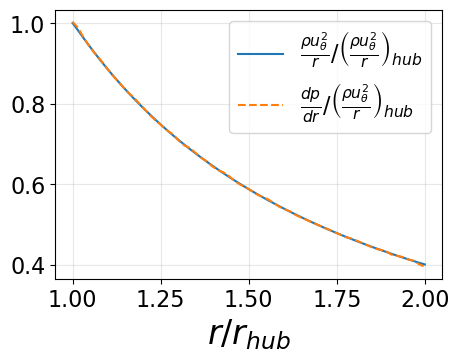

In [31]:
dpdr = np.gradient(pressure, radius, edge_order=1)
rhs = density * (utheta**2 / radius)

norm = density[0]*utheta[0]**2/radius[0]

plt.figure(figsize=(5,3.5))
plt.plot(radius/radius.min(), rhs/norm, label=r'$\frac{\rho u_{\theta}^2}{r} / \left(\frac{\rho u_{\theta}^2}{r}\right)_{hub}$')
plt.plot(radius/radius.min(), dpdr/norm, '--', mfc='none', label=r'$\frac{dp}{dr} / \left(\frac{\rho u_{\theta}^2}{r}\right)_{hub}$')
plt.xlabel(r'$r/r_{hub}$')
# plt.ylabel(r'[Pa/m]')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Pictures/radial_equilibrium_check.pdf', bbox_inches='tight')